# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)

2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Kevin Teng

**Date:** 9/2/26

In [10]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd

#question 1 part 1
df = pd.read_csv('./data/airbnb_hw.csv')

#standarizes prices to just be numbers, removing the $ and , characters
df["Price"] = df["Price"].str.replace('$', '')
df["Price"] = df["Price"].str.replace(',', '')

#converts prices to numeric values
df["Price"] = pd.to_numeric(df["Price"], errors='coerce')

#shows the first 30 values for the Price variable
print(df["Price"].head(30), "\n")

print(df["Price"].describe(), "\n")

#sums up the number of missing value
print(df["Price"].isna().sum(), "\n")

#question 1 part 2
df = pd.read_csv('./data/mn_police_use_of_force.csv')

#removes extra spaces from subject_injury  
df["subject_injury"] = df["subject_injury"].str.strip()

#standardizes the subject_injury variable to be all lowercase
df["subject_injury"] = df["subject_injury"].str.lower()

#sums the number of missing values for the subject_injury variable
missing = df["subject_injury"].isna().sum()
print("Missing values:", missing, "\n")

#calculates missing proportion
print("Percentage of missing values:", missing/len(df["subject_injury"]), "\n")

#cross tabulate
print(pd.crosstab(df["force_type"], df["subject_injury"].fillna("na")), "\n")


0     145
1      37
2      28
3     199
4     549
5     149
6     250
7      90
8     270
9     290
10    170
11     59
12     49
13     68
14    285
15     75
16    145
17    100
18    150
19    700
20    125
21    175
22     90
23     40
24     89
25     95
26     99
27    149
28    499
29     99
Name: Price, dtype: int64 

count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64 

0 

Missing values: 9848 

Percentage of missing values: 0.7619342359767892 

subject_injury                 na    no   yes
force_type                                   
Baton                           2     0     2
Bodily Force                 7051  1093  1286
Chemical Irritant            1421   131    41
Firearm                         0     2     0
Gun Point Display              27    33    44
Improvised Weapon              74    34    40
Less Lethal         

### Question 1 part 1
I removed the '$' abnd ',' characters in the "Price" variable. The reason for this cleaning decision is to better standarize the values so that each Price is formatted as just numbers. I then use pd.to_numeric to convert potential numbers formatted as strings to a float value. I then used head to get the first 30 values of the dataset, to see if my data cleaning was applied correctly. Although 30 is a small sample size, it helps to get a rough idea if the data is consistent. I then used describe to get a rough breakdown of some vital statistics for the dataset. Mainly, the count shows 30478 and there also appears to be 30478 rows in the csv when manually inspected so every data point should be accounted for. Finally, I summed up all the na values for the Prices variable, which returned 0. This indicates that there are no missing prices in the dataset.

### Question 1 part 2
I applied .strip and .lower to the subject_injury variable to standarize the true/false values to be a consistent for the entire dataset. I then summed up all the rows with na value to find the total number of rows with missing values. Taking the missing values and then dividing it by the length of the dataframe (total number of rows), returns a decimal value of 0.7619342359767892. This suggests that 76.19% of the dataset has a missing value for the subject_injury variable. This is a significant concern since this indicates that more than 3/4 of the subject_injury variable is missing. Subject injury does also seems to not be evenly distributed between the force types. Bodily force, for example, has 7051 missing values which is significantly larger than both yes and no combined for that type of subject injury. Simillar patterns are shown for Chemical Irritant and Taser. Sine categories like Maximal Restraint Technique and Less Lethal have all of their values missing. There are also some with no missing values, like Less Lethal Projectile and Firearm.


In [13]:
df = pd.read_excel('./data/GSAF5.xls')
df.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
#question 2 part 2
#removes columns that are empty
df = df.dropna(axis=1, how='all')
df.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


[2026. 2025. 2024. 2023. 2022. 2021. 2020. 2019. 2018. 2017.   nan 2016.
 2015. 2014. 2013. 2012. 2011. 2010. 2009. 2008. 2007. 2006. 2005. 2004.
 2003. 2002. 2001. 2000. 1999. 1998. 1997. 1996. 1995. 1984. 1994. 1993.
 1992. 1991. 1990. 1989. 1969. 1988. 1987. 1986. 1985. 1983. 1982. 1981.
 1980. 1979. 1978. 1977. 1976. 1975. 1974. 1973. 1972. 1971. 1970. 1968.
 1967. 1966. 1965. 1964. 1963. 1962. 1961. 1960. 1959. 1958. 1957. 1956.
 1955. 1954. 1953. 1952. 1951. 1950. 1949. 1948. 1947. 1946. 1945. 1944.
 1943. 1942. 1941. 1940. 1939. 1938. 1937. 1936. 1935. 1934. 1933. 1932.
 1931. 1930. 1929. 1928. 1927. 1926. 1925. 1924. 1923. 1922. 1921. 1920.
 1919. 1918. 1916. 1915. 1914. 1913. 1912. 1911. 1909. 1908. 1907. 1906.
 1905. 1904. 1903. 1902. 1901. 1900. 1899. 1898. 1896. 1895. 1894. 1892.
 1890. 1888. 1887. 1886. 1883. 1881. 1880. 1879. 1878. 1877. 1875. 1873.
 1871. 1870. 1868. 1865. 1864. 1863. 1862. 1859. 1858. 1856. 1852. 1848.
 1847. 1842. 1839. 1837. 1830. 1828. 1817. 1803. 17

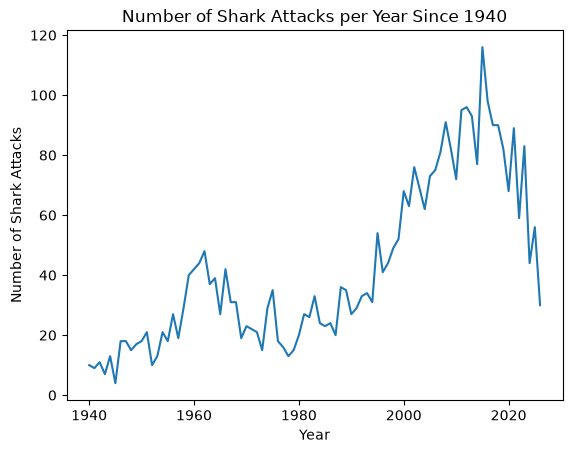

In [54]:
import matplotlib.pyplot as plt
#question 2 part 3
df["Year"] = pd.to_numeric(df["Year"], errors='coerce')
print(df["Year"].unique(), "\n")
df_since_1940 = df[df["Year"] >= 1940]
x = df_since_1940["Year"].value_counts().sort_index()
x.plot()
plt.xlabel("Year")
plt.ylabel("Number of Shark Attacks")
plt.title("Number of Shark Attacks per Year Since 1940")
plt.show()

### Question 2 Part 3

Using .unique, we see that the data has a large range. We see some outliers like 1000, 0, and nan which could be representative of placeholders for missing values or errors in data entry. The dataset typically ranges from 1803 to 2026, but we also see two years in the 1700s. The line graph shows that since 1940, the number of shark attacks were steadily rising before showing a downward trend until the 1980s. The trend of growing shark attacks resumes in the 1980s, and peaks in the mid 2010s, before seeing a sharp decline in recent years.


[43. 27. 71. 21. 69. 31. 13. 12. 17. 35. 19. 11. 20. 38. 39. 16. 22. 55.
 26. 56. 24. 25. 61. 40. 14. 54. 48. 57.  8. 63.  9.  7. 85. 18. 66. 37.
 42. 45. 30. 60. 29. 58. 36. 23. 28. 68. 33. 15. 41. 49. 46. 65. 64. 32.
 10. 62. 52. 44. 47. 59. 50. 34. 77. 73. 67.  6. 53. 51. 75. 70.  4. 74.
  3. 82. 72.  5. 86. 84. 87.  1. 81. 78.]


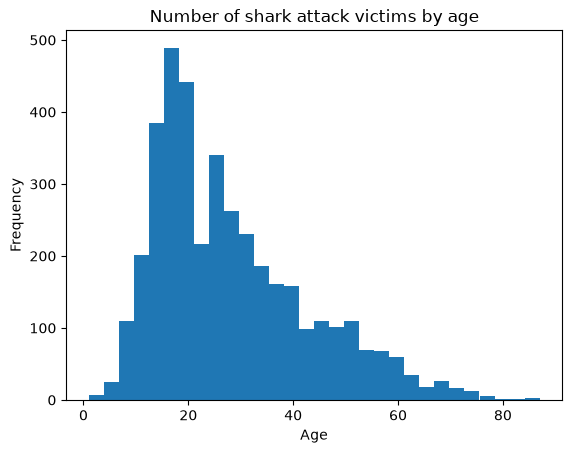

In [33]:
#question 2 part 4

#get all unique values for the Age variable
print(df["Age"].unique())

#filter out rows where Age is missing
df_with_age = df[df["Age"].notna()]

#change number to numeric
df_with_age["Age"] = pd.to_numeric(df_with_age["Age"], errors='coerce')
df_with_age["Age"].plot(kind='hist', bins=30)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Number of shark attack victims by age")
plt.show()

In [44]:
#question 2 part 5

#standarizes the sex variable to be all uppercase and removes extra spaces
df_sex = df["Sex"].str.strip().str.upper()
df_sex = df_sex[df_sex.isna() == False]
num_male = (df_sex == "M").sum()
print("Proportion of male victims:", num_male/len(df_sex))



Proportion of male victims: 0.8505747126436781


### Question 2 Part 5

Around 85.06% of shark attack victims are male

In [50]:
#question 2 part 6
df_type = df["Type"].str.strip().str.title()
print(df_type.unique(), "\n")

df_type = df_type.where(df_type.isin(["Provoked", "Unprovoked"]), "Unknown")
print(df_type.value_counts(), "\n")
num_unprovoked = (df_type == "Unprovoked").sum()
print("Proportion of unprovoked attacks:", num_unprovoked/len(df_type), "\n")


<StringArray>
[         'Unprovoked',            'Provoked',        'Questionable',
          'Watercraft',        'Sea Disaster',                   '?',
                   nan,             'Invalid', 'Under Investigation']
Length: 9, dtype: str 

Type
Unprovoked    3289
Unknown        346
Provoked       313
Name: count, dtype: int64 

Proportion of unprovoked attacks: 0.833080040526849 



### Question 2 Part 6

Approximately 83.31% of shark attacks are unprovoked

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]